In [10]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import os
import re

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

In [2]:
def read_protein_sequence(fasta_file):
    """
    Reads a protein sequence from a FASTA file.

    Parameters:
        fasta_file (str): Path to the FASTA file.

    Returns:
        str: Protein sequence as a single string.
    """
    with open(fasta_file, 'r') as file:
        lines = file.readlines()
        # Skip the header line (starting with '>')
        sequence = ''.join(line.strip() for line in lines if not line.startswith('>'))
    return sequence

def calculate_identity(seq1, seq2):
    """
    Calculate percent sequence identity between two pre-aligned sequences.
    Ignores gaps in the sequences.
    Also returns the ratio of aligned positions to the minimum length of the sequences.
    """
    # Count matches (where both residues are not gaps)
    matches = sum(a == b for a, b in zip(seq1, seq2) if a != '-' and b != '-')
    
    # Count aligned positions (ignoring gaps)
    aligned_positions = sum(1 for a, b in zip(seq1, seq2) if a != '-' and b != '-')

    # Calculate identity percentage
    identity_percentage = (matches / aligned_positions) * 100 if aligned_positions else 0.0

    # Calculate the ratio of aligned positions to the minimum length
    min_length = min(len(seq1), len(seq2))
    alignment_ratio = aligned_positions / min_length if min_length > 0 else 0.0

    return round(identity_percentage, 4), alignment_ratio

In [3]:
### GLOBAL ALIGNMENT ###

In [4]:
PATH_TO_FASTA = os.path.join("..", 'data', 'sequences', 'fasta')
uniprot_to_sequence = {}

# Get protein sequences for mtb tRNA synthetases
for uni in sorted(os.listdir(PATH_TO_FASTA)):
    fasta_file = os.path.join(PATH_TO_FASTA, uni)
    protein_sequence = read_protein_sequence(fasta_file)
    uniprot_to_sequence[uni.removesuffix(".fasta")] = protein_sequence

# Get tRNAs
tRNAs = set(uniprot_to_sequence)

# Get 50 random sequences from mtb differents from the ones in the fasta file (tRNA synthetases)
mtb_proteome = pd.read_csv("../data/mtb_proteome_from_uniprot.tsv", sep='\t')
mtb_proteome = mtb_proteome[~mtb_proteome['Entry'].isin(uniprot_to_sequence)]
mtb_proteome = mtb_proteome.sample(n=25, random_state=42, replace=False)

# Add random sequences to the dictionary
for uni, seq in zip(mtb_proteome['Entry'], mtb_proteome['Sequence']):
    uniprot_to_sequence[uni] = seq

# Get all proteins
uniprots = sorted([i for i in uniprot_to_sequence if i in tRNAs]) + sorted([i for i in uniprot_to_sequence if i not in tRNAs])



In [5]:
# Create and configure the aligner
aligner = PairwiseAligner()
aligner.mode = 'global'  # Needleman–Wunsch algorithm

# Load BLOSUM62 substitution matrix
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")

# Set gap penalties
aligner.open_gap_score = -10  
aligner.extend_gap_score = -1

# Identity matrix
identity_matrix = np.zeros((len(uniprots), len(uniprots)))
prop_matrix = np.zeros((len(uniprots), len(uniprots)))
identity_dict = {}
identity_prop = {}

# Compute pairwise identities
for i in range(len(uniprots)):
    for j in range(i, len(uniprots)):

        # Align sequences
        seq1 = uniprot_to_sequence[uniprots[i]]
        seq2 = uniprot_to_sequence[uniprots[j]]
        alignment = aligner.align(seq1, seq2)[0]  # Take the best alignment
        aligned_seq1, aligned_seq2 = [k for k in alignment]

        # Calculate sequence identity
        identity, prop = calculate_identity(aligned_seq1, aligned_seq2)

        # Store results
        identity_matrix[i, j] = identity
        identity_matrix[j, i] = identity  # symmetric
        prop_matrix[i, j] = prop
        prop_matrix[j, i] = prop  # symmetric
        identity_dict[(uniprots[i], uniprots[j])] = identity
        identity_dict[(uniprots[j], uniprots[i])] = identity
        identity_prop[(uniprots[i], uniprots[j])] = prop
        identity_prop[(uniprots[j], uniprots[i])] = prop

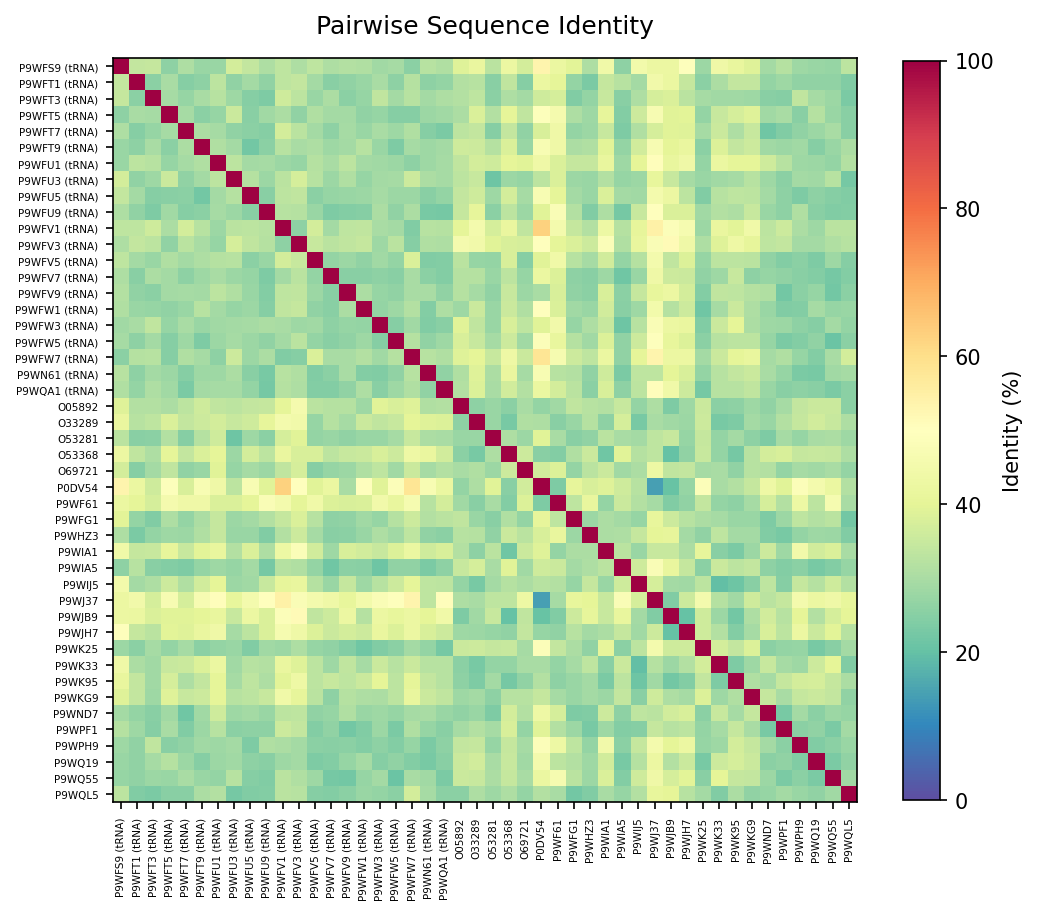

In [6]:
labels = [i + " (tRNA)" if i in tRNAs else i for i in uniprots]
size = 5

plt.figure(figsize=(8, 8))
plt.imshow(identity_matrix, vmin=0, cmap='Spectral_r')
plt.xticks(range(len(labels)), labels, rotation=90, size=size)
plt.yticks(range(len(labels)), labels, size=size)
plt.title("Pairwise Sequence Identity", pad=12)
plt.colorbar(shrink=0.8, label="Identity (%)")
plt.show()

In [7]:
h1 = [identity_dict[i] for i in sorted(identity_dict) if i[0] in tRNAs and i[1] in tRNAs]
h2 = [identity_dict[i] for i in sorted(identity_dict) if (i[0] in tRNAs and i[1] not in tRNAs) or (i[0] not in tRNAs and i[1] in tRNAs)]  # Just for consistency

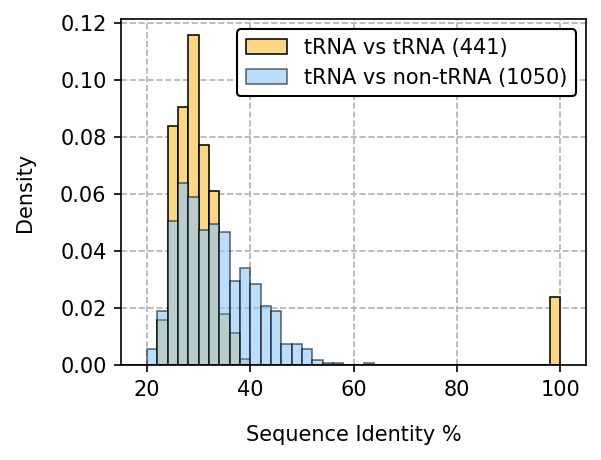

In [8]:
bins = [i for i in range(0, 101, 2)]
plt.figure(figsize=(4, 3))
plt.hist(h1, bins=bins, label=f"tRNA vs tRNA ({len(h1)})", color='#FAD782', edgecolor='black', linewidth=0.75, zorder=2, density=True)
plt.hist(h2, bins=bins, label=f"tRNA vs non-tRNA ({len(h2)})", color='#8DC7FA', edgecolor='black', linewidth=0.75, zorder=2, density=True, alpha=0.6)

plt.xlabel("Sequence Identity %", labelpad=12)
plt.ylabel("Density", labelpad=12)   
plt.grid(linestyle='--', zorder=-2)
plt.xlim(15, 105)
plt.legend(edgecolor='k', framealpha=1)
plt.show()

In [32]:
### CLUSTAL OMEGA RUN IN EMBL WEBSITE ###
# https://www.ebi.ac.uk/jdispatcher/msa/clustalo

In [33]:
# Load the file
with open("../processed/sequences/MSA_ClustalOmega/clustalo-I20250414-162824-0073-80384311-p1m.pim") as f:
    lines = f.readlines()

# Extract protein names and matrix values
labels = []
matrix = []

for line in lines:
    if re.match(r"\s*\d+:", line):
        parts = line.strip().split()
        label = parts[1]
        values = list(map(float, parts[2:]))
        labels.append(label)
        matrix.append(values)

# Create DataFrame
df = pd.DataFrame(matrix, index=labels, columns=labels)

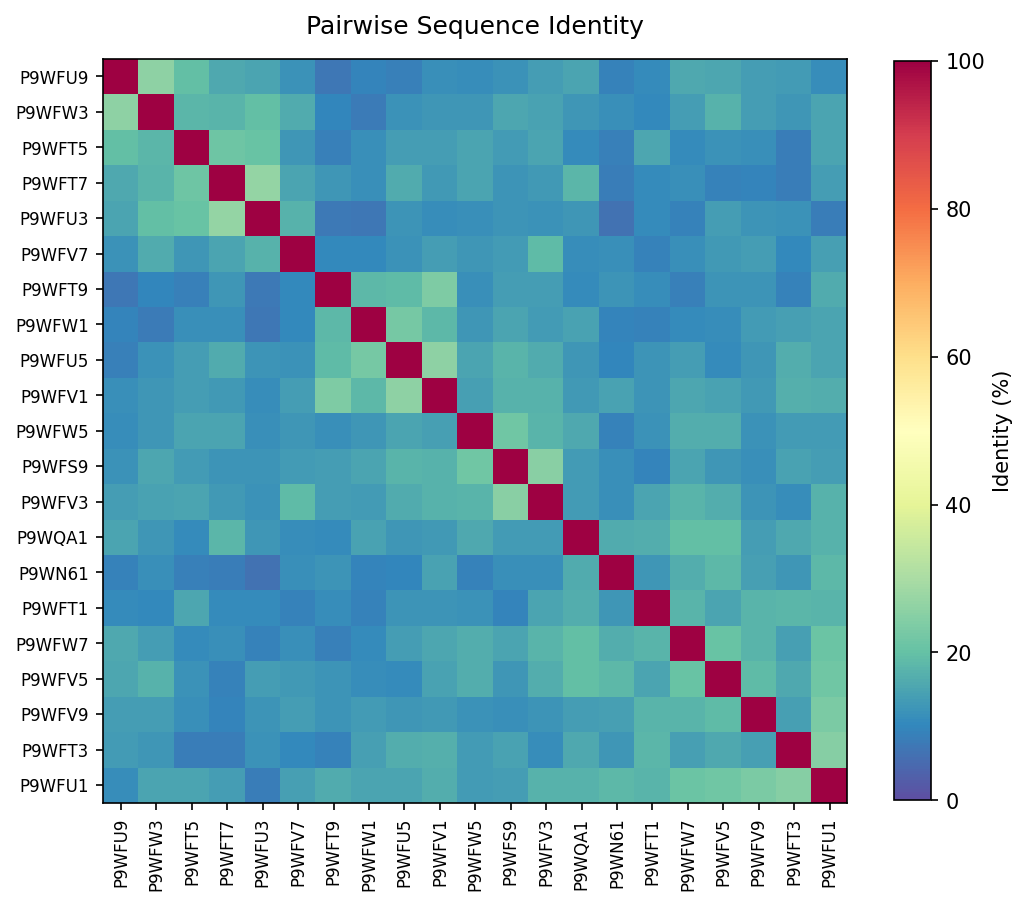

In [34]:
labels = [i.split("|")[0] for i in labels]
size = 8

plt.figure(figsize=(8, 8))
plt.imshow(np.array(df.values), vmin=0, cmap='Spectral_r')
plt.xticks(range(len(labels)), labels, rotation=90, size=size)
plt.yticks(range(len(labels)), labels, size=size)
plt.title("Pairwise Sequence Identity", pad=12)
plt.colorbar(shrink=0.8, label="Identity (%)")
plt.show()